# TNG Group Catalog : TNG300 vs. TNG50

## Import Basic Libraries

In [30]:
import numpy as np
import pandas as pd
import glob
import sys
import h5py
#from netCDF4 import Dataset
from datetime import datetime
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

import pyarrow as pa
import pyarrow.parquet as pq

from functools import reduce
import operator
import gc

In [31]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'stix'

## Define SparkSession and sparkContext

In [3]:
# PySpark packages
from pyspark import SparkContext   
from pyspark.sql import SparkSession

import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark import Row
from pyspark.sql.window import Window as W


spark = SparkSession.builder \
    .master("yarn") \
    .appName("spark-shell") \
    .config("spark.driver.maxResultSize", "32g") \
    .config("spark.driver.memory", "32g") \
    .config("spark.executor.memory", "7g") \
    .config("spark.executor.cores", "1") \
    .config("spark.executor.instances", "150") \
    .getOrCreate()


sc = spark.sparkContext
sc.setCheckpointDir("hdfs://spark00:54310/tmp/checkpoints")

spark.conf.set("spark.sql.debug.maxToStringFields", 500)
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

In [4]:
sc.getConf().getAll()[:10]

[('spark.driver.memory', '32g'),
 ('spark.app.startTime', '1742524551504'),
 ('spark.driver.appUIAddress', 'http://spark00:4040'),
 ('spark.driver.maxResultSize', '32g'),
 ('spark.ui.proxyBase', '/proxy/application_1740026882285_0049'),
 ('spark.master', 'yarn'),
 ('spark.executor.id', 'driver'),
 ('spark.sql.warehouse.dir',
  'file:/home/shong/work/illustris/notebook/spark-warehouse'),
 ('spark.executor.instances', '150'),
 ('spark.submit.deployMode', 'client')]

## Read All Subhalo Parquet Files

- About IllustrisTNG, https://www.illustris-project.org/data/docs/specifications/
- About TNG300, https://www.tng-project.org/data/downloads/TNG300-1/

In [5]:
data50path = "hdfs://spark00:54310/common/data/illustris/tng50/snapshot99/groupcat/"
data300path = "hdfs://spark00:54310/common/data/illustris/tng300/snapshot99/groupcat/"

In [6]:
outpath = "hdfs://spark00:54310/common/data/illustris/tng50/snapshot99/reduced/"

In [8]:
%%time
# Read all parquets in the directory
sdf = spark.read.option("header","true").option("recursiveFileLookup","true").parquet(data50path)
ldf = spark.read.option("header","true").option("recursiveFileLookup","true").parquet(data300path)

CPU times: user 1.49 ms, sys: 1.86 ms, total: 3.35 ms
Wall time: 4.53 s


In [9]:
sdf.printSchema()

root
 |-- SubhaloBHMass: float (nullable = true)
 |-- SubhaloBHMdot: float (nullable = true)
 |-- SubhaloBfldDisk: float (nullable = true)
 |-- SubhaloBfldHalo: float (nullable = true)
 |-- SubhaloCM: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloFlag: boolean (nullable = true)
 |-- SubhaloGasMetalFractions: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsHalfRad: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsMaxRad: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsSfr: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsSfrWeighted: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetallicity: float (nullable = true)
 |-- SubhaloGasMetallicityHalfRad: float (nullable = true)
 |-- SubhaloGasMetallicityMaxRad: fl

In [10]:
ldf.printSchema()

root
 |-- SubhaloBHMass: float (nullable = true)
 |-- SubhaloBHMdot: float (nullable = true)
 |-- SubhaloBfldDisk: float (nullable = true)
 |-- SubhaloBfldHalo: float (nullable = true)
 |-- SubhaloCM: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloFlag: boolean (nullable = true)
 |-- SubhaloGasMetalFractions: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsHalfRad: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsMaxRad: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsSfr: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetalFractionsSfrWeighted: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- SubhaloGasMetallicity: float (nullable = true)
 |-- SubhaloGasMetallicityHalfRad: float (nullable = true)
 |-- SubhaloGasMetallicityMaxRad: fl

## Mass Function

In [9]:
%%time
rawdf.select(['SubhaloMass']).describe().show()

+-------+--------------------+
|summary|         SubhaloMass|
+-------+--------------------+
|  count|             5688113|
|   mean|0.033329695025624786|
| stddev|  7.3405361282682495|
|    min|        7.0952636E-5|
|    max|           13289.604|
+-------+--------------------+

CPU times: user 0 ns, sys: 3.82 ms, total: 3.82 ms
Wall time: 16 s


> Total number of subhalos is `5,688,113`

#### Plot the histogram of `SubhaloMass`

In [11]:
%%time
# Step 1: Convert 'SubhaloMass' to Pandas
smass = sdf.select("SubhaloMass").toPandas()["SubhaloMass"]
lmass = ldf.select("SubhaloMass").toPandas()["SubhaloMass"]

CPU times: user 112 ms, sys: 72.1 ms, total: 184 ms
Wall time: 33.9 s


In [12]:
# Step 2: Define Log-Spaced Bins
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(0.0001), np.log10(1e5), num_bins)

In [17]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'stix'

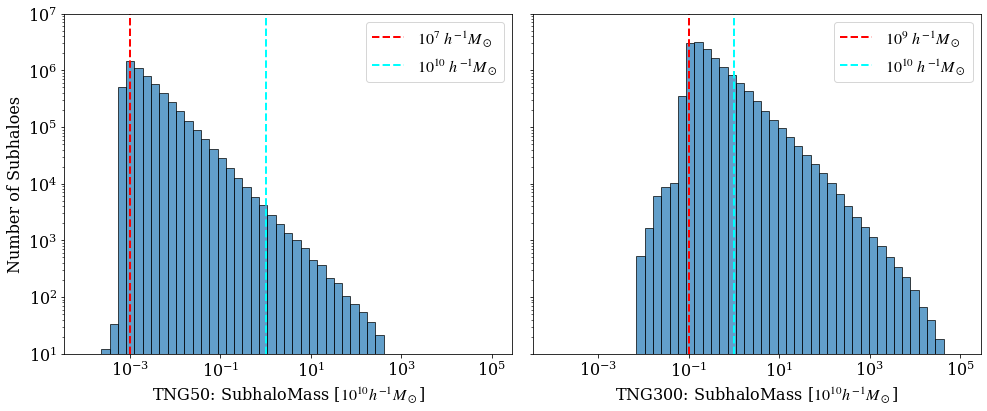

In [63]:
# Create a 1-row, 2-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)  # Share y-axis for consistent comparison

# Plot for smass
axes[0].hist(smass, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
axes[0].set_ylim(1e1, 1e7)
axes[0].set_ylabel("Number of Subhaloes")
axes[0].set_xlabel(r'TNG50: SubhaloMass [$10^{10} h^{-1} M_\odot $]')
#axes[0].set_title("TNG50 SubHalo Mass Function")
axes[0].set_xscale("log")
axes[0].axvline(x=10**-3, color='red', linestyle='--', linewidth=2, label=r'$10^{7}~ h^{-1} M_\odot$')
axes[0].axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
axes[0].legend()

# Plot for lmass
axes[1].hist(lmass, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
axes[1].set_ylim(1e1, 1e7)
axes[1].set_xlabel(r'TNG300: SubhaloMass [$10^{10} h^{-1} M_\odot $]')
#axes[1].set_ylabel("Number of Subhaloes")
#axes[1].set_title("TNG300 SubHalo Mass Function")
axes[1].set_xscale("log")
axes[1].axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
axes[1].axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
axes[1].legend()

# Tidy layout
plt.tight_layout()


# Step 5: Save the Figure as PDF
plt.savefig("tng-both-subhalo-massfunc.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng-both-subhalo-massfunc.png", format="png", bbox_inches="tight")

# Step 6: Show Plot
plt.show()

- Simulation Completeness Limit near $10^{7} M_\odot$ vs. $10^{9} M_\odot$

### Explode SubhaloMassType

In [23]:
# Define the band names
mass_names = ["m_gas", "m_dm", "dummy", "tr_dummy", "m_star", "m_bh"]

In [24]:
# Select and create new columns
for idx, mtype in enumerate(mass_names):
    sdf = sdf.withColumn(mtype, F.col('SubhaloMassType').getItem(idx))

In [25]:
# Select and create new columns
for idx, mtype in enumerate(mass_names):
    ldf = ldf.withColumn(mtype, F.col('SubhaloMassType').getItem(idx))

In [26]:
%%time
sdf.select(['SubhaloMass',"m_dm", "m_gas", "m_star", "m_bh"]).show(5,truncate=False)

+-----------+-----------+-----+------------+----+
|SubhaloMass|m_dm       |m_gas|m_star      |m_bh|
+-----------+-----------+-----+------------+----+
|0.025727784|0.025296362|0.0  |4.3142235E-4|0.0 |
|0.02883109 |0.02883109 |0.0  |0.0         |0.0 |
|0.028777229|0.028769618|0.0  |7.611349E-6 |0.0 |
|0.02883109 |0.02883109 |0.0  |0.0         |0.0 |
|0.028800353|0.028800353|0.0  |0.0         |0.0 |
+-----------+-----------+-----+------------+----+
only showing top 5 rows

CPU times: user 2.22 ms, sys: 534 µs, total: 2.75 ms
Wall time: 265 ms


In [27]:
%%time
ldf.select(['SubhaloMass',"m_dm", "m_gas", "m_star", "m_bh"]).show(5,truncate=False)

+-----------+----------+----------+-----------+------------+
|SubhaloMass|m_dm      |m_gas     |m_star     |m_bh        |
+-----------+----------+----------+-----------+------------+
|0.17527081 |0.17527081|0.0       |0.0        |0.0         |
|8.560058   |7.735816  |0.80635756|0.017060202|8.238204E-4 |
|0.1872211  |0.1872211 |0.0       |0.0        |0.0         |
|9.599063   |8.974662  |0.6060134 |0.017164726|0.0012226128|
|0.11950283 |0.11950283|0.0       |0.0        |0.0         |
+-----------+----------+----------+-----------+------------+
only showing top 5 rows

CPU times: user 2.62 ms, sys: 73 µs, total: 2.69 ms
Wall time: 195 ms


In [67]:
%%time
# Step 1: Convert 'SubhaloMass' to Pandas
smdm = sdf.select("m_dm").toPandas()["m_dm"]
lmdm = ldf.select("m_dm").toPandas()["m_dm"]

CPU times: user 104 ms, sys: 73.1 ms, total: 177 ms
Wall time: 16.3 s


In [68]:
%%time
smstar = sdf.select("m_star").toPandas()["m_star"]
lmstar = ldf.select("m_star").toPandas()["m_star"]

CPU times: user 94.7 ms, sys: 85 ms, total: 180 ms
Wall time: 16.6 s


In [75]:
smdm.head()

0    0.025296
1    0.028831
2    0.028770
3    0.028831
4    0.028800
Name: m_dm, dtype: float32

In [69]:
smstar.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5688113 entries, 0 to 5688112
Series name: m_star
Non-Null Count    Dtype  
--------------    -----  
5688113 non-null  float32
dtypes: float32(1)
memory usage: 21.7 MB


In [70]:
smdm.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5688113 entries, 0 to 5688112
Series name: m_dm
Non-Null Count    Dtype  
--------------    -----  
5688113 non-null  float32
dtypes: float32(1)
memory usage: 21.7 MB


In [71]:
# Step 2: Define Log-Spaced Bins
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(0.0001), np.log10(1e5), num_bins)

In [72]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'stix'

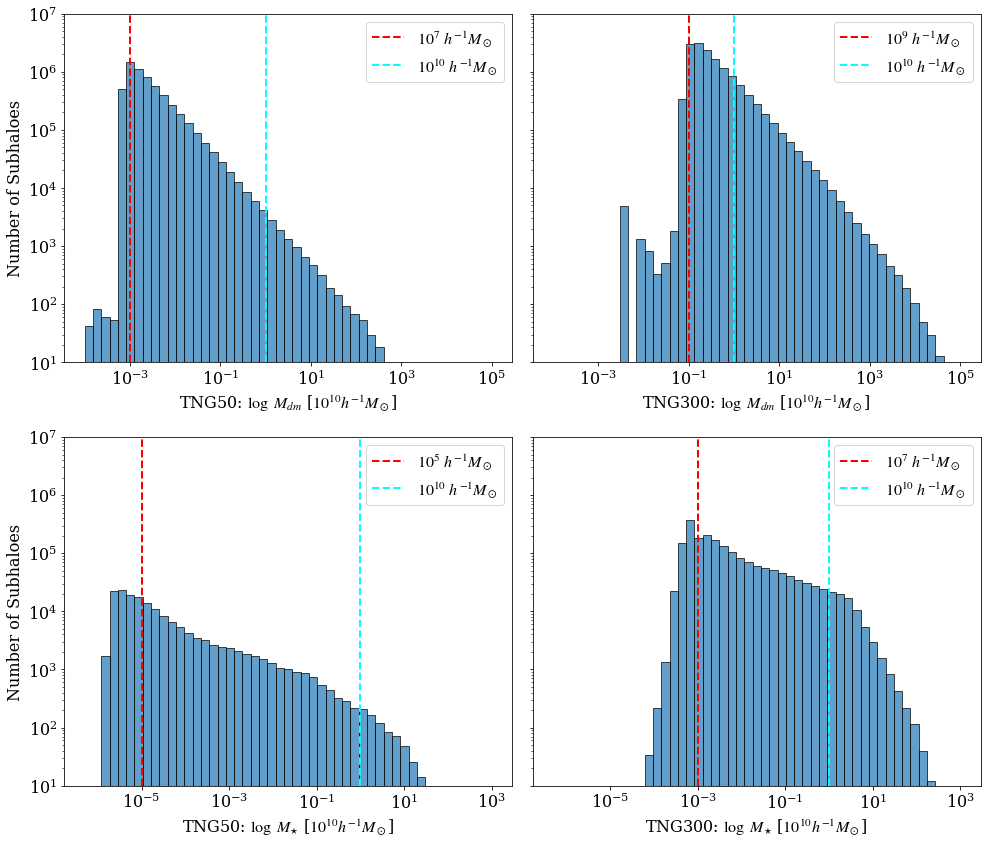

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True)

# Step 2: Define Log-Spaced Bins
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(0.0001), np.log10(1e5), num_bins)

# Top-left: smdm
axes[0, 0].hist(smdm, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
axes[0, 0].set_ylim(1e1, 1e7)
axes[0, 0].set_ylabel("Number of Subhaloes")
axes[0, 0].set_xlabel(r'TNG50: $\log~M_{dm}$ [$10^{10} h^{-1} M_\odot $]')
axes[0, 0].set_xscale("log")
axes[0, 0].axvline(x=10**-3, color='red', linestyle='--', linewidth=2, label=r'$10^{7}~ h^{-1} M_\odot$')
axes[0, 0].axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
axes[0, 0].legend()

# Top-right: lmdm
axes[0, 1].hist(lmdm, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
axes[0, 1].set_ylim(1e1, 1e7)
axes[0, 1].set_xlabel(r'TNG300: $\log~M_{dm}$ [$10^{10} h^{-1} M_\odot $]')
axes[0, 1].set_xscale("log")
axes[0, 1].axvline(x=10**-1, color='red', linestyle='--', linewidth=2, label=r'$10^{9}~ h^{-1} M_\odot$')
axes[0, 1].axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
axes[0, 1].legend()

# Change the logbins 
num_bins = 50  # Adjust as needed
#log_bins = np.logspace(np.log10(subhalo_mass.min()), np.log10(subhalo_mass.max()), num_bins)
log_bins = np.logspace(np.log10(5e-7), np.log10(1e3), num_bins)

# Bottom-left: smstar
axes[1, 0].hist(smstar, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
axes[1, 0].set_ylim(1e1, 1e7)
axes[1, 0].set_ylabel("Number of Subhaloes")
axes[1, 0].set_xlabel(r'TNG50: $\log~M_{\star}$ [$10^{10} h^{-1} M_\odot $]')
axes[1, 0].set_xscale("log")
axes[1, 0].axvline(x=10**-5, color='red', linestyle='--', linewidth=2, label=r'$10^{5}~ h^{-1} M_\odot$')
axes[1, 0].axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
axes[1, 0].legend()

# Bottom-right: lmstar
axes[1, 1].hist(lmstar, bins=log_bins, edgecolor='black', alpha=0.7, log=True)
axes[1, 1].set_ylim(1e1, 1e7)
axes[1, 1].set_xlabel(r'TNG300: $\log~M_{\star}$ [$10^{10} h^{-1} M_\odot $]')
axes[1, 1].set_xscale("log")
axes[1, 1].axvline(x=10**-3, color='red', linestyle='--', linewidth=2, label=r'$10^{7}~ h^{-1} M_\odot$')
axes[1, 1].axvline(x=10**0, color='cyan', linestyle='--', linewidth=2, label=r'$10^{10}~ h^{-1} M_\odot$')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("tng-both-dm-star-massfunc.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng-both-dm-star-massfunc.png", format="png", bbox_inches="tight")
plt.show()

#### Assigning `isubhalotype`

In [33]:
# Compute `isubhalotype`
sdf = sdf.withColumn(
    "isubhalotype",
    (F.when(F.col("m_dm") > 0, 1).otherwise(0) +
     F.when(F.col("m_gas") > 0, 4).otherwise(0) +
     F.when(F.col("m_star") > 0, 8).otherwise(0) +
     F.when(F.col("m_bh") > 0, 16).otherwise(0))
)

In [34]:
# Compute `isubhalotype`
ldf = ldf.withColumn(
    "isubhalotype",
    (F.when(F.col("m_dm") > 0, 1).otherwise(0) +
     F.when(F.col("m_gas") > 0, 4).otherwise(0) +
     F.when(F.col("m_star") > 0, 8).otherwise(0) +
     F.when(F.col("m_bh") > 0, 16).otherwise(0))
)

In [35]:
%%time
sdf.select(['SubhaloMass',"m_dm", "m_gas", "m_star", "m_bh",'isubhalotype']) \
.show(5,truncate=False)

+-----------+-----------+-----+------------+----+------------+
|SubhaloMass|m_dm       |m_gas|m_star      |m_bh|isubhalotype|
+-----------+-----------+-----+------------+----+------------+
|0.025727784|0.025296362|0.0  |4.3142235E-4|0.0 |9           |
|0.02883109 |0.02883109 |0.0  |0.0         |0.0 |1           |
|0.028777229|0.028769618|0.0  |7.611349E-6 |0.0 |9           |
|0.02883109 |0.02883109 |0.0  |0.0         |0.0 |1           |
|0.028800353|0.028800353|0.0  |0.0         |0.0 |1           |
+-----------+-----------+-----+------------+----+------------+
only showing top 5 rows

CPU times: user 2.63 ms, sys: 0 ns, total: 2.63 ms
Wall time: 520 ms


In [36]:
%%time
ldf.select(['SubhaloMass',"m_dm", "m_gas", "m_star", "m_bh",'isubhalotype']) \
.show(5,truncate=False)

+-----------+----------+----------+-----------+------------+------------+
|SubhaloMass|m_dm      |m_gas     |m_star     |m_bh        |isubhalotype|
+-----------+----------+----------+-----------+------------+------------+
|0.17527081 |0.17527081|0.0       |0.0        |0.0         |1           |
|8.560058   |7.735816  |0.80635756|0.017060202|8.238204E-4 |29          |
|0.1872211  |0.1872211 |0.0       |0.0        |0.0         |1           |
|9.599063   |8.974662  |0.6060134 |0.017164726|0.0012226128|29          |
|0.11950283 |0.11950283|0.0       |0.0        |0.0         |1           |
+-----------+----------+----------+-----------+------------+------------+
only showing top 5 rows

CPU times: user 3.22 ms, sys: 0 ns, total: 3.22 ms
Wall time: 1.48 s


In [37]:
# Compute the group count for each `isubhalotype`
hist_subtype_sdf = sdf.groupBy("isubhalotype").agg(F.count("*").alias("count"))
hist_subtype_sdf = hist_subtype_sdf.orderBy(F.col("count").desc())

In [38]:
%%time
hist_subtype_spdf = hist_subtype_sdf.toPandas()

CPU times: user 8.8 ms, sys: 0 ns, total: 8.8 ms
Wall time: 14.9 s


In [40]:
# Compute the group count for each `isubhalotype`
hist_subtype_ldf = ldf.groupBy("isubhalotype").agg(F.count("*").alias("count"))
hist_subtype_ldf = hist_subtype_ldf.orderBy(F.col("count").desc())

In [41]:
%%time
hist_subtype_lpdf = hist_subtype_ldf.toPandas()

CPU times: user 6.98 ms, sys: 0 ns, total: 6.98 ms
Wall time: 16.3 s


In [42]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 14})
plt.rcParams['mathtext.fontset'] = 'stix'

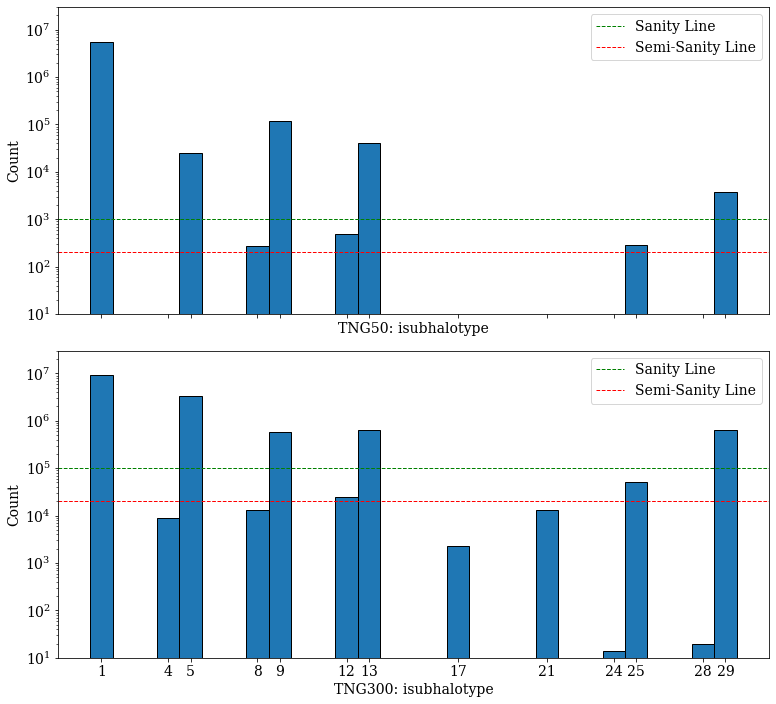

In [48]:
# Create figure with 2 rows and 1 column
fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Top panel: hist_subtype_spdf (was bottom before)
axes[0].set_yscale("log")
axes[0].bar(hist_subtype_spdf["isubhalotype"], hist_subtype_spdf["count"], width=1.0, edgecolor="black")
axes[0].axhline(y=1e3, color='green', linestyle='--', linewidth=1, label='Sanity Line')
axes[0].axhline(y=2e2, color='red', linestyle='--', linewidth=1, label='Semi-Sanity Line')
axes[0].set_xlabel("TNG50: isubhalotype")
axes[0].set_ylabel("Count")
axes[0].legend(loc=0)
axes[0].set_ylim(1e1, 3e7)
axes[0].set_xticks(hist_subtype_spdf["isubhalotype"])

# Bottom panel: hist_subtype_lpdf (was top before)
axes[1].set_yscale("log")
axes[1].bar(hist_subtype_lpdf["isubhalotype"], hist_subtype_lpdf["count"], width=1.0, edgecolor="black")
axes[1].axhline(y=1e5, color='green', linestyle='--', linewidth=1, label='Sanity Line') 
axes[1].axhline(y=2e4, color='red', linestyle='--', linewidth=1, label='Semi-Sanity Line')
axes[1].set_xlabel("TNG300: isubhalotype")
axes[1].set_ylabel("Count")
axes[1].legend(loc=0)
axes[1].set_ylim(1e1, 3e7)
axes[1].set_xticks(hist_subtype_lpdf["isubhalotype"])

# Layout and save
plt.tight_layout()
plt.savefig("tng-both-isubhalotype-hist.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng-both-isubhalotype-hist.png", format="png", bbox_inches="tight")
plt.show()

- **1: DM only**
- 4: Gas only (what?!?)
- **5: DM + Gas**
- 8: Star only (what?!?)
- *9:* **DM + Star (no gas?!? strong feedback?)**
- *12: Gas + Star (no dm?!?, tidally stripped subhalo?)*
- **13: DM + Gas + Star (good)** 
- 17: DM + BH (what?!?)
- 21: DM + Gas + BH (no star?!? what?!?) 
- 24: Star + BH (what?!?) 
- *25:* **DM + Star + BH (no gas?!? even stronger feedback?)**
- 28: Gas + Star + BH 
- **29: DM + Gas + Star + BH**

In [49]:
hist_subtype_spdf

,isubhalotype,count
0,1,5499951
1,9,117358
2,13,41090
3,5,24889
4,29,3765
5,12,500
6,25,286
7,8,268
8,4,6


In [50]:
hist_subtype_lpdf

,isubhalotype,count
0,1,9245720
1,5,3267700
2,13,641501
3,29,632154
4,9,586390
5,25,49998
6,12,24952
7,21,13356
8,8,12899
9,4,8749


### SFR vs. Stellar Mass

In [51]:
%%time
# Convert to Pandas and remove rows with zero or negative values
spdf = sdf.select(['m_star', 'SubhaloSFR']).toPandas()
spdf = spdf[(spdf["m_star"] > 0) & (spdf["SubhaloSFR"] > 0)]  # Remove zeros & negatives
spdf = spdf.dropna()  # Remove any NaN values
# Convert data to log10 scale
spdf["log_m_star"] = np.log10(spdf["m_star"])
spdf["log_SubhaloSFR"] = np.log10(spdf["SubhaloSFR"])

CPU times: user 70.8 ms, sys: 48.2 ms, total: 119 ms
Wall time: 6.85 s


In [52]:
spdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17531 entries, 2048 to 5660447
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          17531 non-null  float32
 1   SubhaloSFR      17531 non-null  float32
 2   log_m_star      17531 non-null  float32
 3   log_SubhaloSFR  17531 non-null  float32
dtypes: float32(4)
memory usage: 410.9 KB


In [88]:
%%time
# Convert to Pandas and remove rows with zero or negative values
lpdf = ldf.select(['m_star', 'SubhaloSFR']).toPandas()
lpdf = lpdf[(lpdf["m_star"] > 0) & (lpdf["SubhaloSFR"] > 0)]  # Remove zeros & negatives
lpdf = lpdf.dropna()  # Remove any NaN values
# Convert data to log10 scale
lpdf["log_m_star"] = np.log10(lpdf["m_star"])
lpdf["log_SubhaloSFR"] = np.log10(lpdf["SubhaloSFR"])

CPU times: user 177 ms, sys: 75.2 ms, total: 252 ms
Wall time: 15.8 s


In [89]:
lpdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 552121 entries, 1 to 14472212
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   m_star          552121 non-null  float32
 1   SubhaloSFR      552121 non-null  float32
 2   log_m_star      552121 non-null  float32
 3   log_SubhaloSFR  552121 non-null  float32
dtypes: float32(4)
memory usage: 12.6 MB


In [86]:
%%time
# Convert to Pandas and remove rows with zero or negative values
sdgs = sdf.filter(sdf.isubhalotype == 13).select(['m_star', 'SubhaloSFR']).toPandas()
sdgs = sdgs[(sdgs["m_star"] > 0) & (sdgs["SubhaloSFR"] > 0)]  # Remove zeros & negatives
sdgs = sdgs.dropna()  # Remove any NaN values
# Convert data to log10 scale
sdgs["log_m_star"] = np.log10(sdgs["m_star"])
sdgs["log_SubhaloSFR"] = np.log10(sdgs["SubhaloSFR"])

CPU times: user 14.8 ms, sys: 0 ns, total: 14.8 ms
Wall time: 13.8 s


In [87]:
sdgs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13373 entries, 0 to 41088
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          13373 non-null  float32
 1   SubhaloSFR      13373 non-null  float32
 2   log_m_star      13373 non-null  float32
 3   log_SubhaloSFR  13373 non-null  float32
dtypes: float32(4)
memory usage: 313.4 KB


In [90]:
%%time
# Convert to Pandas and remove rows with zero or negative values
ldgs = ldf.filter(ldf.isubhalotype == 13).select(['m_star', 'SubhaloSFR']).toPandas()
ldgs = ldgs[(ldgs["m_star"] > 0) & (ldgs["SubhaloSFR"] > 0)]  # Remove zeros & negatives
ldgs = ldgs.dropna()  # Remove any NaN values
# Convert data to log10 scale
ldgs["log_m_star"] = np.log10(ldgs["m_star"])
ldgs["log_SubhaloSFR"] = np.log10(ldgs["SubhaloSFR"])

CPU times: user 33.2 ms, sys: 5.02 ms, total: 38.2 ms
Wall time: 9.82 s


In [91]:
ldgs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 75462 entries, 2 to 641499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          75462 non-null  float32
 1   SubhaloSFR      75462 non-null  float32
 2   log_m_star      75462 non-null  float32
 3   log_SubhaloSFR  75462 non-null  float32
dtypes: float32(4)
memory usage: 1.7 MB


In [92]:
%%time
# Convert to Pandas and remove rows with zero or negative values
sdgsb = sdf.filter(sdf.isubhalotype == 29).select(['m_star', 'SubhaloSFR']).toPandas()
sdgsb = sdgsb[(sdgsb["m_star"] > 0) & (sdgsb["SubhaloSFR"] > 0)]  # Remove zeros & negatives
sdgsb = sdgsb.dropna()  # Remove any NaN values
# Convert data to log10 scale
sdgsb["log_m_star"] = np.log10(sdgsb["m_star"])
sdgsb["log_SubhaloSFR"] = np.log10(sdgsb["SubhaloSFR"])

CPU times: user 11.9 ms, sys: 0 ns, total: 11.9 ms
Wall time: 6.5 s


In [93]:
sdgsb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3690 entries, 0 to 3764
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          3690 non-null   float32
 1   SubhaloSFR      3690 non-null   float32
 2   log_m_star      3690 non-null   float32
 3   log_SubhaloSFR  3690 non-null   float32
dtypes: float32(4)
memory usage: 86.5 KB


In [94]:
%%time
# Convert to Pandas and remove rows with zero or negative values
ldgsb = ldf.filter(ldf.isubhalotype == 29).select(['m_star', 'SubhaloSFR']).toPandas()
ldgsb = ldgsb[(ldgsb["m_star"] > 0) & (ldgsb["SubhaloSFR"] > 0)]  # Remove zeros & negatives
ldgsb = ldgsb.dropna()  # Remove any NaN values
# Convert data to log10 scale
ldgsb["log_m_star"] = np.log10(ldgsb["m_star"])
ldgsb["log_SubhaloSFR"] = np.log10(ldgsb["SubhaloSFR"])

CPU times: user 31.9 ms, sys: 7.23 ms, total: 39.2 ms
Wall time: 9.74 s


In [95]:
ldgsb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 453720 entries, 0 to 632153
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   m_star          453720 non-null  float32
 1   SubhaloSFR      453720 non-null  float32
 2   log_m_star      453720 non-null  float32
 3   log_SubhaloSFR  453720 non-null  float32
dtypes: float32(4)
memory usage: 10.4 MB


In [96]:
%%time
# Convert to Pandas and remove rows with zero or negative values
sgs = sdf.filter(sdf.isubhalotype == 12).select(['m_star', 'SubhaloSFR']).toPandas()
sgs = sgs[(sgs["m_star"] > 0) & (sgs["SubhaloSFR"] > 0)]  # Remove zeros & negatives
sgs = sgs.dropna()  # Remove any NaN values
# Convert data to log10 scale
sgs["log_m_star"] = np.log10(sgs["m_star"])
sgs["log_SubhaloSFR"] = np.log10(sgs["SubhaloSFR"])

CPU times: user 9.48 ms, sys: 247 µs, total: 9.72 ms
Wall time: 6.7 s


In [97]:
sgs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 468 entries, 0 to 498
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          468 non-null    float32
 1   SubhaloSFR      468 non-null    float32
 2   log_m_star      468 non-null    float32
 3   log_SubhaloSFR  468 non-null    float32
dtypes: float32(4)
memory usage: 11.0 KB


In [98]:
%%time
# Convert to Pandas and remove rows with zero or negative values
lgs = ldf.filter(ldf.isubhalotype == 12).select(['m_star', 'SubhaloSFR']).toPandas()
lgs = lgs[(lgs["m_star"] > 0) & (lgs["SubhaloSFR"] > 0)]  # Remove zeros & negatives
lgs = lgs.dropna()  # Remove any NaN values
# Convert data to log10 scale
lgs["log_m_star"] = np.log10(lgs["m_star"])
lgs["log_SubhaloSFR"] = np.log10(lgs["SubhaloSFR"])

CPU times: user 19.3 ms, sys: 217 µs, total: 19.5 ms
Wall time: 9.9 s


In [99]:
lgs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22919 entries, 0 to 24951
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   m_star          22919 non-null  float32
 1   SubhaloSFR      22919 non-null  float32
 2   log_m_star      22919 non-null  float32
 3   log_SubhaloSFR  22919 non-null  float32
dtypes: float32(4)
memory usage: 537.2 KB


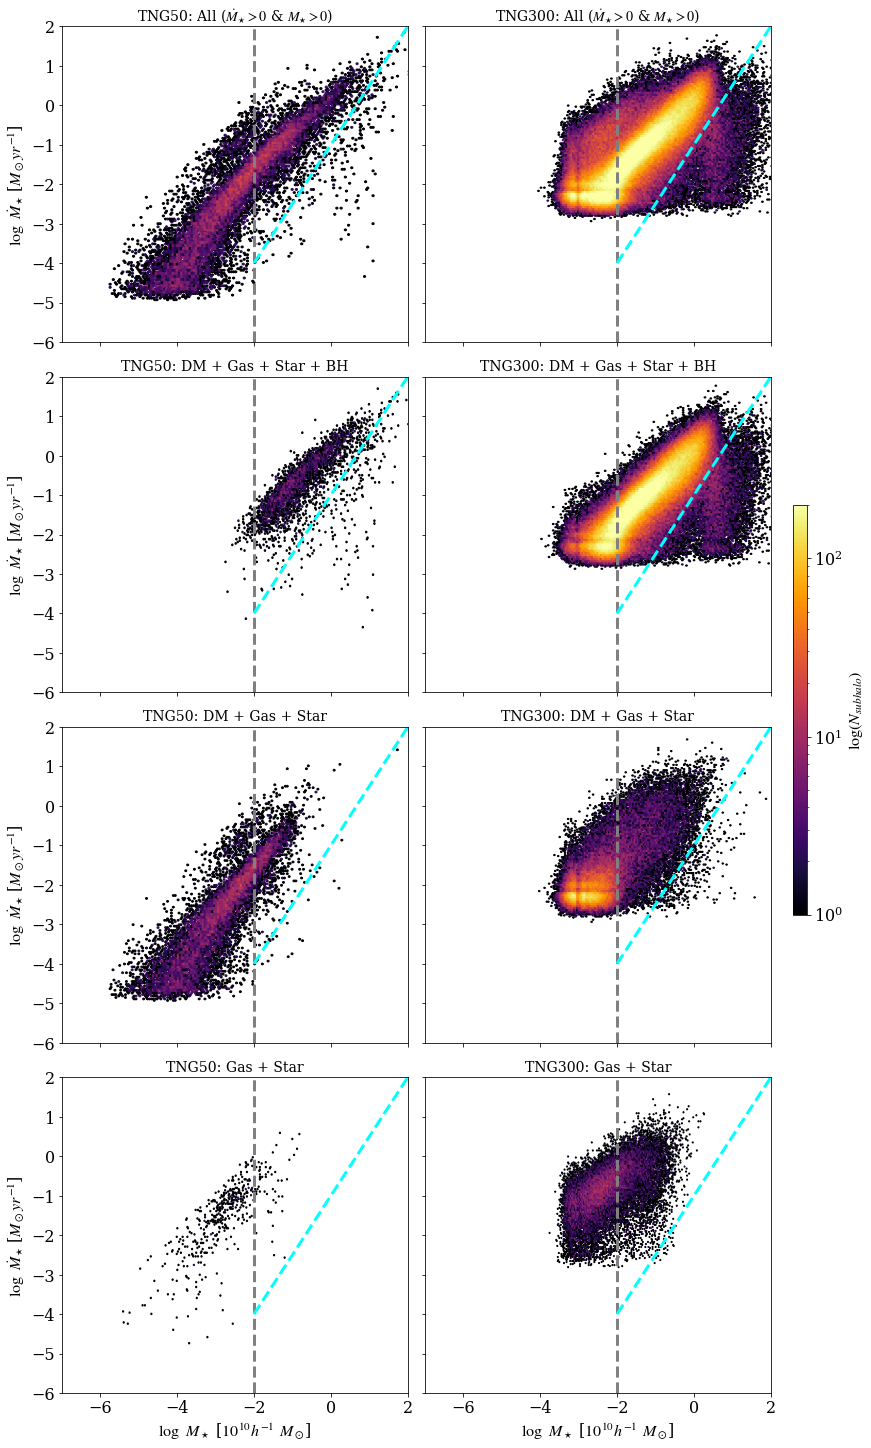

In [127]:
# Create a 2×2 figure
fig, axes = plt.subplots(4, 2, figsize=(12, 20), sharex=True, sharey=True, constrained_layout=True)

# Define datasets and titles for each panel
datasets = [spdf,lpdf,sdgsb, ldgsb,sdgs, ldgs, sgs, lgs]
titles = [r'TNG50: All ($\dot{M}_{\star} > 0$ & $M_{\star} > 0$)', \
          r'TNG300: All ($\dot{M}_{\star} > 0$ & $M_{\star} > 0$)', \
          "TNG50: DM + Gas + Star + BH" , "TNG300: DM + Gas + Star + BH", \
          "TNG50: DM + Gas + Star", "TNG300: DM + Gas + Star", \
          "TNG50: Gas + Star", "TNG300: Gas + Star"]

# Loop through each subplot manually
for ax, data, title in zip(axes.flatten(), datasets, titles):
    # Create hexbin plot
    hb = ax.hexbin(data["log_m_star"], data["log_SubhaloSFR"], gridsize=150, 
                   cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=200)

    # Overplot reference lines
    ax.axvline(x=-2, color='grey', linestyle='--', linewidth=3)
    ax.plot([-2, 2], [-4, 2], color='cyan', linestyle='--', linewidth=3)

    # Set axis limits
    ax.set_xlim(-7, 2)
    ax.set_ylim(-6, 2)

    # Labels and title
    ax.set_title(title, fontsize=14)

# Set common x and y labels (only for bottom-left & left-most panels)
axes[3, 0].set_xlabel(r'$\log$ $M_\star$ [$10^{10} h^{-1}$ $M_\odot $]')
axes[3, 1].set_xlabel(r'$\log$ $M_\star$ [$10^{10} h^{-1}$ $M_\odot $]')
axes[0, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')
axes[1, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')
axes[2, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')
axes[3, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')

# Add a single colorbar for all panels
cbar = fig.colorbar(hb, ax=axes[:, -1], shrink=0.3, aspect=30, \
                    label=r'$\log(N_{subhalo})$')

# Adjust layout
#plt.tight_layout()

# Save the Figure
plt.savefig("tng-both_4x2_bimodality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng-both_4x2_bimodality.png", format="png", bbox_inches="tight")

# Show the plot
plt.show()

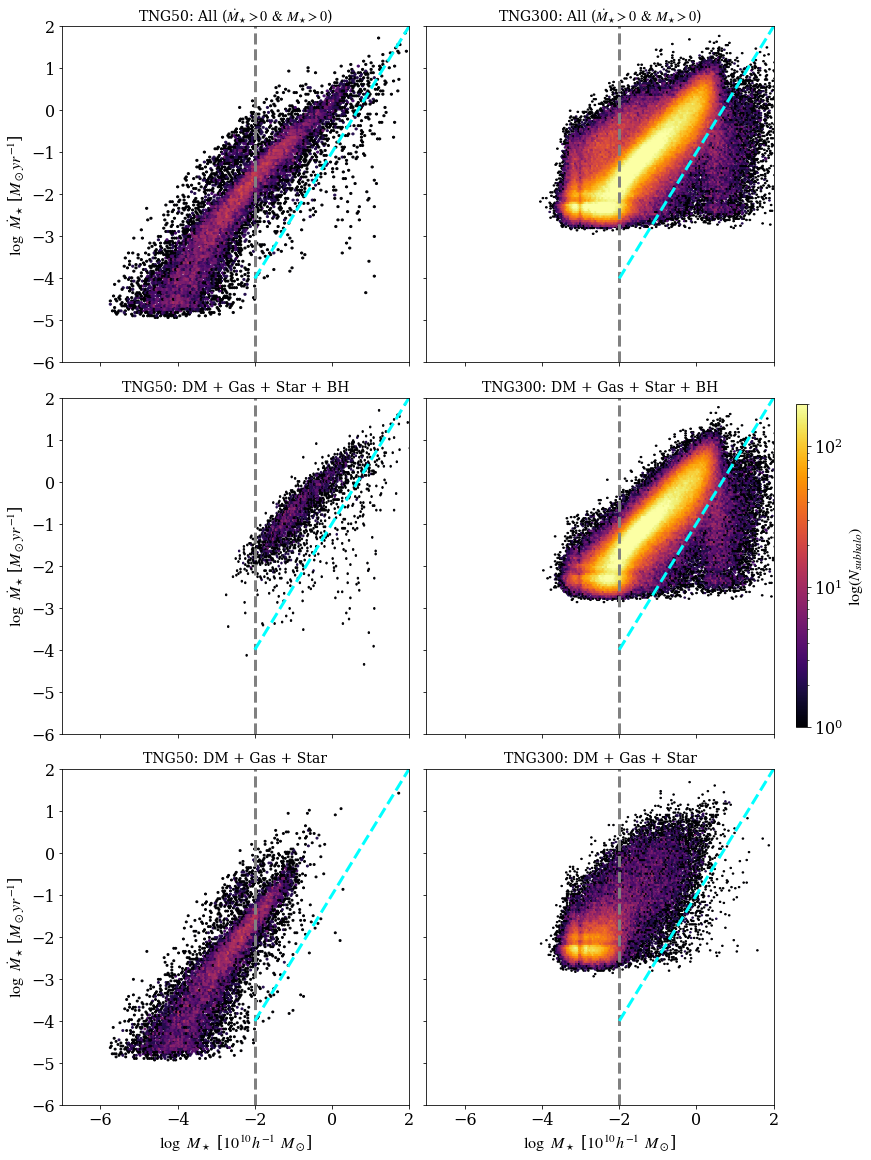

In [132]:
# Create a 2×2 figure
fig, axes = plt.subplots(3, 2, figsize=(12, 16), sharex=True, sharey=True, constrained_layout=True)

# Define datasets and titles for each panel
datasets = [spdf,lpdf,sdgsb, ldgsb,sdgs, ldgs, sgs, lgs]
titles = [r'TNG50: All ($\dot{M}_{\star} > 0$ $&$ $M_{\star} > 0$)', \
          r'TNG300: All ($\dot{M}_{\star} > 0$ $&$ $M_{\star} > 0$)', \
          "TNG50: DM + Gas + Star + BH" , "TNG300: DM + Gas + Star + BH", \
          "TNG50: DM + Gas + Star", "TNG300: DM + Gas + Star"]

# Loop through each subplot manually
for ax, data, title in zip(axes.flatten(), datasets, titles):
    # Create hexbin plot
    hb = ax.hexbin(data["log_m_star"], data["log_SubhaloSFR"], gridsize=150, 
                   cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=200)

    # Overplot reference lines
    ax.axvline(x=-2, color='grey', linestyle='--', linewidth=3)
    ax.plot([-2, 2], [-4, 2], color='cyan', linestyle='--', linewidth=3)

    # Set axis limits
    ax.set_xlim(-7, 2)
    ax.set_ylim(-6, 2)

    # Labels and title
    ax.set_title(title, fontsize=14)

# Set common x and y labels (only for bottom-left & left-most panels)
axes[2, 0].set_xlabel(r'$\log$ $M_\star$ [$10^{10} h^{-1}$ $M_\odot $]')
axes[2, 1].set_xlabel(r'$\log$ $M_\star$ [$10^{10} h^{-1}$ $M_\odot $]')
axes[0, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')
axes[1, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')
axes[2, 0].set_ylabel(r'$\log$ $\dot{M}_{\star}$ [$M_\odot yr^{-1}$]')


# Add a single colorbar for all panels
cbar = fig.colorbar(hb, ax=axes[:, -1], shrink=0.3, aspect=30, \
                    label=r'$\log(N_{subhalo})$')

# Adjust layout
#plt.tight_layout()

# Save the Figure
plt.savefig("tng-both_3x2_bimodality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng-both_3x2_bimodality.png", format="png", bbox_inches="tight")

# Show the plot
plt.show()

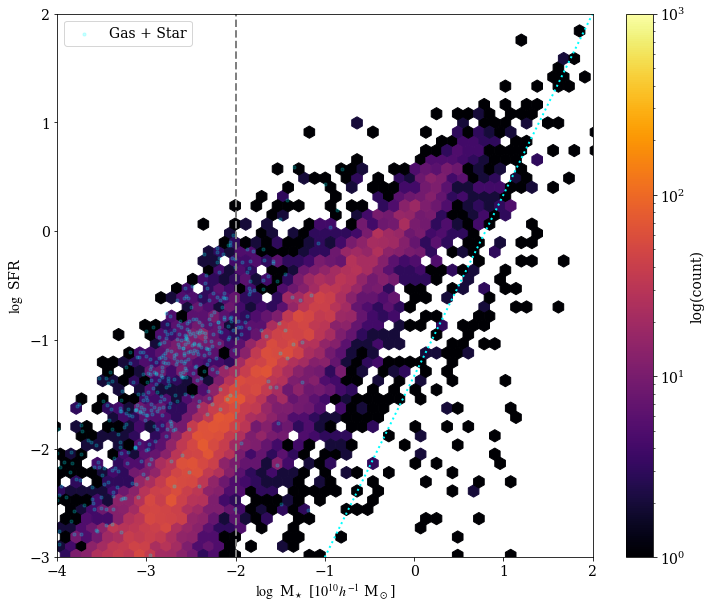

In [75]:

# Create hexbin plot on log-transformed values
plt.figure(figsize=(12,10))
hb = plt.hexbin(pdf["log_m_star"], pdf["log_SubhaloSFR"], gridsize=70, \
                cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1000)

plt.axvline(x=-2, color='grey', linestyle='--', linewidth=2)
# Plot the line from (-1, -2) to (2, 1)
plt.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=2)


# **Set X and Y limits (Modify values as needed)**
plt.xlim(-4, 2)  # Example: Log(Mass) from 10^8 to 10^12
plt.ylim(-3, 2)  # Example: Log(SFR) from 10^-3 to 10^2

# **No need for log scale on axes since data is already log-transformed**
plt.xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
plt.ylabel(r'$\log$ SFR')
#plt.title("Hexbin Density Plot of Log-Converted SubhaloMass vs SubhaloSFR")

# Add color bar
plt.colorbar(label='log(count)')
# Overplot scatter plot for `isubhalotype == 29`
plt.scatter(gs["log_m_star"], gs["log_SubhaloSFR"], color='cyan', s=10, alpha=0.2, label="Gas + Star")

plt.legend(loc=0)

# Step 5: Save the Figure as PDF
plt.savefig("tng50_gs_bimordality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng50_gs_bimordality.png", format="png", bbox_inches="tight")


# Show the plot
plt.show()

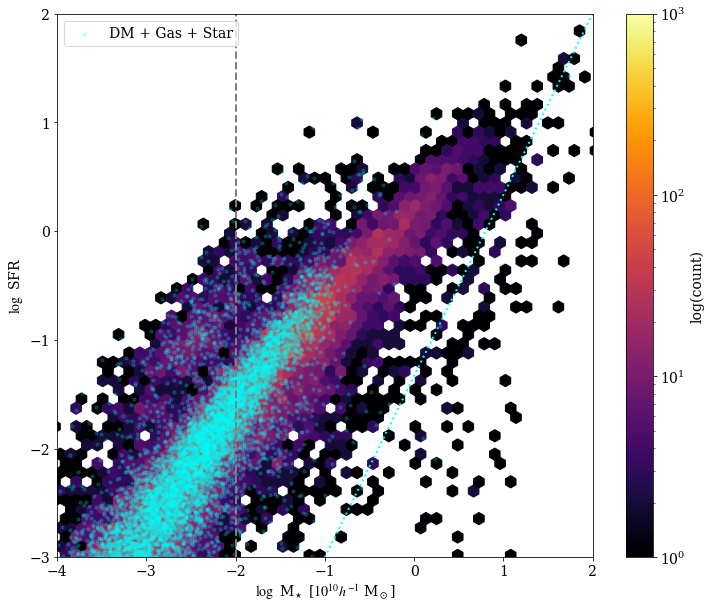

In [76]:

# Create hexbin plot on log-transformed values
plt.figure(figsize=(12,10))
hb = plt.hexbin(pdf["log_m_star"], pdf["log_SubhaloSFR"], gridsize=70, \
                cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1000)

plt.axvline(x=-2, color='grey', linestyle='--', linewidth=2)
# Plot the line from (-1, -2) to (2, 1)
plt.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=2)


# **Set X and Y limits (Modify values as needed)**
plt.xlim(-4, 2)  # Example: Log(Mass) from 10^8 to 10^12
plt.ylim(-3, 2)  # Example: Log(SFR) from 10^-3 to 10^2

# **No need for log scale on axes since data is already log-transformed**
plt.xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
plt.ylabel(r'$\log$ SFR')
#plt.title("Hexbin Density Plot of Log-Converted SubhaloMass vs SubhaloSFR")

# Add color bar
plt.colorbar(label='log(count)')
# Overplot scatter plot for `isubhalotype == 29`
plt.scatter(dgs["log_m_star"], dgs["log_SubhaloSFR"], color='cyan', s=10, alpha=0.2, label="DM + Gas + Star")

plt.legend(loc=2)

# Step 5: Save the Figure as PDF
plt.savefig("tng50_dgs_bimordality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng50_dgs_bimordality.png", format="png", bbox_inches="tight")


# Show the plot
plt.show()

### *u-r* color vs. Stellar Mass

#### define `df` for `m_star > 0`

In [77]:
df = rawdf.filter(rawdf.m_star >0)

In [78]:
df.cache()

DataFrame[SubhaloBHMass: float, SubhaloBHMdot: float, SubhaloBfldDisk: float, SubhaloBfldHalo: float, SubhaloCM: array<float>, SubhaloFlag: boolean, SubhaloGasMetalFractions: array<float>, SubhaloGasMetalFractionsHalfRad: array<float>, SubhaloGasMetalFractionsMaxRad: array<float>, SubhaloGasMetalFractionsSfr: array<float>, SubhaloGasMetalFractionsSfrWeighted: array<float>, SubhaloGasMetallicity: float, SubhaloGasMetallicityHalfRad: float, SubhaloGasMetallicityMaxRad: float, SubhaloGasMetallicitySfr: float, SubhaloGasMetallicitySfrWeighted: float, SubhaloGrNr: int, SubhaloHalfmassRad: float, SubhaloHalfmassRadType: array<float>, SubhaloIDMostbound: bigint, SubhaloLen: int, SubhaloLenType: array<int>, SubhaloMass: float, SubhaloMassInHalfRad: float, SubhaloMassInHalfRadType: array<float>, SubhaloMassInMaxRad: float, SubhaloMassInMaxRadType: array<float>, SubhaloMassInRad: float, SubhaloMassInRadType: array<float>, SubhaloMassType: array<float>, SubhaloParent: int, SubhaloPos: array<float

In [79]:
%%time
df.select(['m_star',"U", "r"]).show(5,truncate=False)

+------------+----------+----------+
|m_star      |U         |r         |
+------------+----------+----------+
|4.3142235E-4|-9.993896 |-11.323773|
|7.611349E-6 |-6.155203 |-6.9911666|
|2.1393814E-6|-4.785105 |-5.6202364|
|2.1446423E-5|-7.2751317|-8.175338 |
|1.4064997E-4|-9.098034 |-10.231216|
+------------+----------+----------+
only showing top 5 rows

CPU times: user 2.32 ms, sys: 294 µs, total: 2.61 ms
Wall time: 1.06 s


In [80]:
# Add `color_ur` column as U - r
df = df.withColumn("color_ur", F.col("U") - F.col("r"))

In [81]:
%%time
df.select(['m_star',"U", "r",'color_ur']).show(5,truncate=False)

+------------+----------+----------+----------+
|m_star      |U         |r         |color_ur  |
+------------+----------+----------+----------+
|4.3142235E-4|-9.993896 |-11.323773|1.3298779 |
|7.611349E-6 |-6.155203 |-6.9911666|0.8359637 |
|2.1393814E-6|-4.785105 |-5.6202364|0.83513117|
|2.1446423E-5|-7.2751317|-8.175338 |0.9002061 |
|1.4064997E-4|-9.098034 |-10.231216|1.1331825 |
+------------+----------+----------+----------+
only showing top 5 rows

CPU times: user 2.52 ms, sys: 0 ns, total: 2.52 ms
Wall time: 56.3 ms


In [82]:
%%time
df.select(["U", "r",'color_ur']).describe().show()

+-------+------------------+------------------+-------------------+
|summary|                 U|                 r|           color_ur|
+-------+------------------+------------------+-------------------+
|  count|            163267|            163267|             163267|
|   mean|-7.542572760211493|-8.437240845314466| 0.8946680851029746|
| stddev| 3.162322608337038|  3.12918626662741|0.23512980518349133|
|    min|        -24.347532|        -26.074598|         -1.5048733|
|    max|         -3.754477|        -4.5888696|          2.0529585|
+-------+------------------+------------------+-------------------+

CPU times: user 4.17 ms, sys: 0 ns, total: 4.17 ms
Wall time: 8.74 s


In [83]:
%%time
# Convert to Pandas and remove rows with zero or negative values
ppdf = df.select(['m_star', 'color_ur']).toPandas()
ppdf = ppdf.dropna()  # Remove any NaN values
# Convert data to log10 scale
ppdf["log_m_star"] = np.log10(ppdf["m_star"])

CPU times: user 13.9 ms, sys: 2.16 ms, total: 16.1 ms
Wall time: 254 ms


In [84]:
ppdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163267 entries, 0 to 163266
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   m_star      163267 non-null  float32
 1   color_ur    163267 non-null  float32
 2   log_m_star  163267 non-null  float32
dtypes: float32(3)
memory usage: 1.9 MB


In [85]:
# plot settings
plt.rc('font', family='serif') 
#plt.rc('font', serif='Times New Roman') 
plt.rcParams.update({'font.size': 14})
plt.rcParams['mathtext.fontset'] = 'stix'

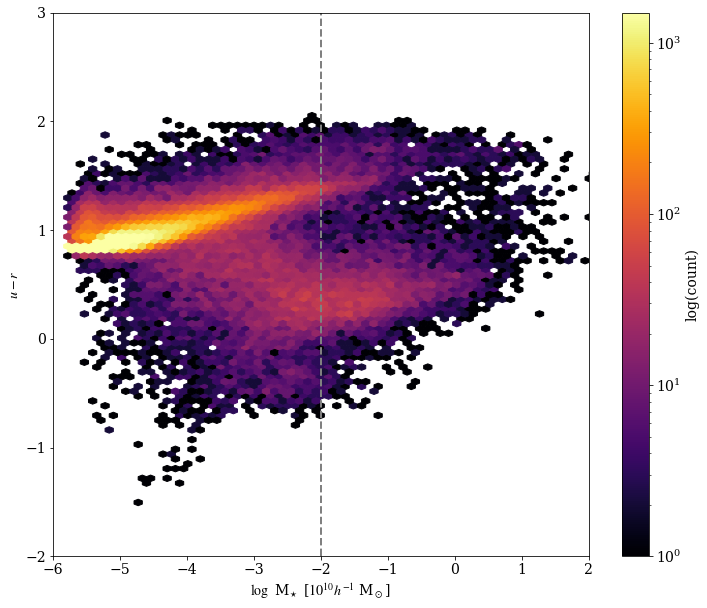

In [87]:
# Create hexbin plot on log-transformed values
plt.figure(figsize=(12,10))
hb = plt.hexbin(ppdf["log_m_star"], ppdf["color_ur"], gridsize=70, \
                cmap='inferno', bins='log', mincnt=1, vmin=1, vmax=1500)

plt.axvline(x=-2, color='grey', linestyle='--', linewidth=2)
# Plot the line from (-1, -2) to (2, 1)
#plt.plot([-1, 2], [-3, 2], color='cyan', linestyle=':', linewidth=2)


# **Set X and Y limits (Modify values as needed)**
plt.xlim(-6, 2)  # Example: Log(Mass) from 10^8 to 10^12
plt.ylim(-2, 3)  # Example: Log(SFR) from 10^-3 to 10^2

# **No need for log scale on axes since data is already log-transformed**
plt.xlabel(r'$\log$ M$_\star$ [$10^{10} h^{-1}$ M$_\odot $]')
plt.ylabel(r'$u - r$')
#plt.title("Hexbin Density Plot of Log-Converted SubhaloMass vs SubhaloSFR")

# Add color bar
plt.colorbar(label='log(count)')
# Overplot scatter plot for `isubhalotype == 29`
#plt.scatter(gs["log_m_star"], gs["log_SubhaloSFR"], color='cyan', s=10, alpha=0.2, label="Gas + Star")

#plt.legend(loc=0)

# Step 5: Save the Figure as PDF
plt.savefig("tng50_color_bimordality.pdf", format="pdf", bbox_inches="tight")
plt.savefig("tng50_color_bimordality.png", format="png", bbox_inches="tight")


# Show the plot
plt.show()